# Programa de Capacitação de Processamento Digital de Sinais


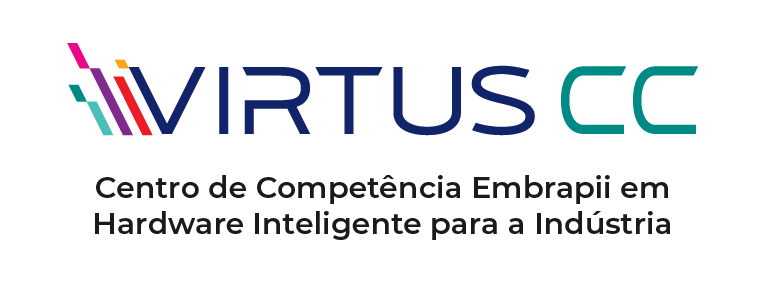


### Desenvolvido por:
-   Elmer Pimentel Farias


## Exercícios do Capítulo 3 — Processamento Digital de Sinais

Capítulo 3 do livro **Processamento Digital de Sinais** de Paulo S. R. Diniz.

## Sobre o Capítulo 3

**O Capítulo 3 apresenta os conceitos de DFT e implementações de FFT:**

- Análise de Frequência de Sinais Discretos: Por que representar sinais no domínio da frequência.

- A Transformada de Fourier Discreta (DFT): A versão computacional da análise de Fourier.

- Definição e Propriedades Principais.

A **Transformada Rápida de Fourier (FFT)** não é uma nova transformada, mas sim uma família de algoritmos extremamente eficientes para calcular a DFT.

- A ineficiência do cálculo direto da DFT: O cálculo da DFT diretamente por sua definição exige um número de operações na ordem de **$O(N^2)$**, onde $N$ é o número de amostras. Isso torna o processo inviável para sequências longas.

- O princípio da "divisão e conquista": A base dos algoritmos FFT é quebrar uma DFT de $N$ pontos em DFTs menores, de forma recursiva. Os resultados dessas DFTs menores são então combinados para produzir o resultado final.


- Algoritmos Clássicos: Os algoritmos mais comuns que implementam essa estratégia são:
    - Decimação no Tempo (DIT - *Decimation-In-Time*)
    - Decimação na Frequência (DIF - *Decimation-In-Frequency*)


- O ganho de performance: Ao utilizar a estratégia de "divisão e conquista", os algoritmos FFT reduzem drasticamente a complexidade computacional para a ordem de **$O(N \log N)$**, representando um ganho de performance massivo e tornando a análise de frequência uma ferramenta prática na computação moderna.

- Métodos Overlap-Add e Overlap-Save 

- Convolução Circular vs. Linear: Como a DFT modifica a operação de convolução e como usar isso a nosso favor.

## Objetivos Principais:
-  Implementar DFT manualmente e verificar propriedades como simetria e periodicidade.
-   Implementar o algoritmo da FFT e comparar tempo de execução e resultado com a DFT
-  Simular convolução circular via DFT e comparar com convolução linear.
- Testar ferramentas de aceleração de código, tais como Numba e CuPy.

## Vamos utilizar bibliotecas Python para representação e manipulação de sinais discretos

- NumPy : https://numpy.org/doc/stable/user/absolute_beginners.html
- Matplotlib.pyplot: https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html

# Importando as Bibliotecas


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  
from numba import njit, jit , vectorize , prange

#  Transformada Discreta de Fourier (DFT) e Análise do Código

## 1. Introdução à DFT

A **Transformada Discreta de Fourier (DFT)** permite transformar um sinal do **domínio do tempo** para o **domínio da frequência**.


Para um sinal discreto \(x[n]\) de comprimento \(N\), a DFT é:

$$
X[k] \;=\; \sum_{n=0}^{N-1} x[n]\,e^{-j\frac{2\pi k n}{N}}, \qquad k = 0,1,\dots,N-1.
$$

Para normalização (preservar energia), usa-se:

$$
X_{\mathrm{norm}}[k] \;=\; \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} x[n]\,e^{-j\frac{2\pi k n}{N}}.
$$


## 2. Zero Padding e Truncamento

Quando o tamanho do sinal \( L \) **não coincide** com o tamanho escolhido para a DFT \( N \), duas situações podem ocorrer:

### 2.1 Zero Padding (\( L < N \))
Adiciona zeros ao final do sinal para que ele tenha comprimento \( N \).  
Essa técnica **não altera o conteúdo do sinal**, mas aumenta a **resolução na frequência**.

$$
x_{zp}[n] =
\begin{cases}
x[n], & 0 \le n < L,\\[4pt]
0, & L \le n < N.
\end{cases}
$$

### 2.2 Truncamento (\( L > N \))
Corta as amostras excedentes do sinal para que ele caiba em \( N \).  
Essa técnica **modifica o sinal original**, podendo introduzir distorções no espectro.

$$
x_{\text{tr}}[n] = x[n], \qquad 0 \le n < N.
$$

Sinal x1[n] com zero padding: 50 amostras
Sinal x2[n] cortado: 100 amostras


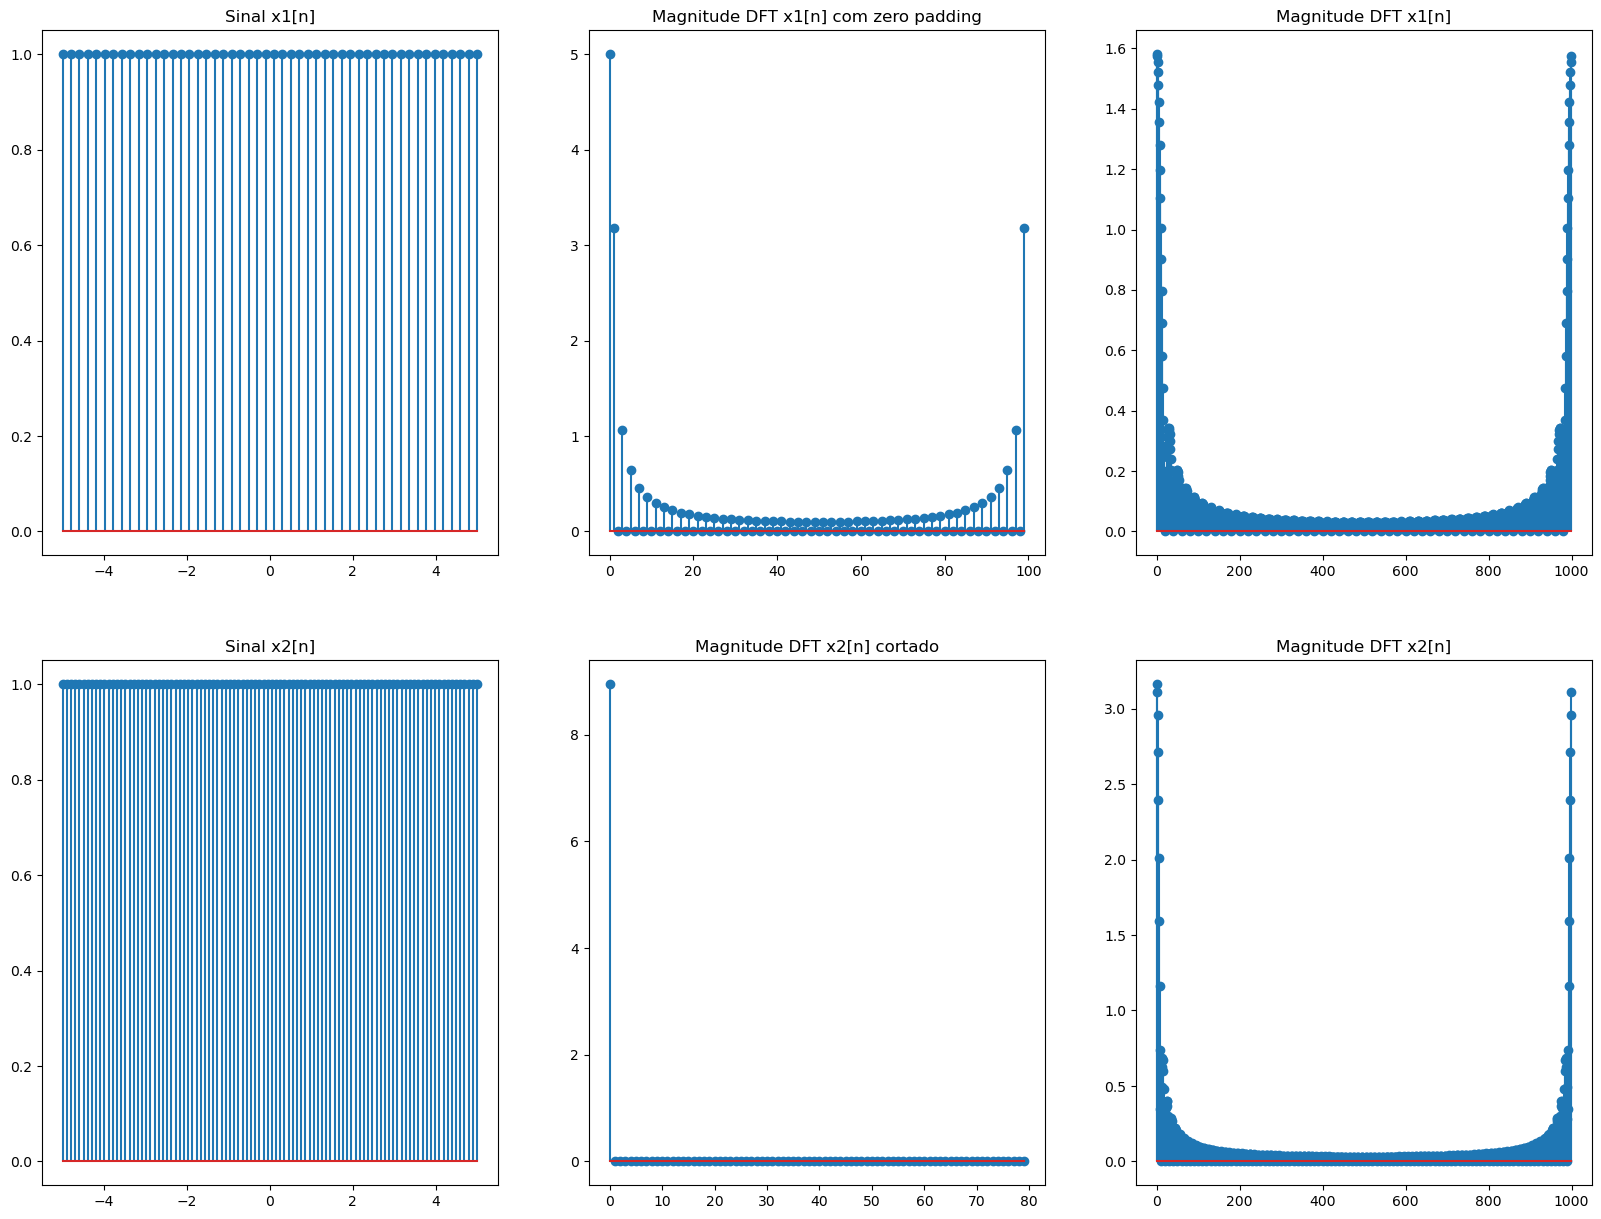

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

from numba import njit, jit , vectorize , prange
@njit(parallel=True)
def DFT_func(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in prange(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT

L1= 50
N1= 100

L2=100
N2=80 

n1= np.linspace(-5,5,L1)
n2= np.linspace(-5,5,L2)

x1= np.where(np.abs(n1)<10,1,0) #sinal retangular
x2= np.where(np.abs(n2)<10,1,0) #sinal retangular



X1_DFT= DFT_func(x1,N=N1) #DFT do sinal x1, L1=50 < N1=100, com zero padding

X2_DFT= DFT_func(x2,N=N2) #DFT do sinal x2, L2=100 > N2=80, truncado

X3_DFT= DFT_func(x1,N=1000) #DFT do sinal x2, L2=100 < N=1000

X4_DFT= DFT_func(x2,N=1000) #DFT do sinal x2, L2=100 > N=1000

fig , axs= plt.subplots(2,3, figsize=(20,15))

axs[0,0].stem(n1,x1)
axs[0,0].set_title('Sinal x1[n]')
axs[1,0].stem(n2,x2)
axs[1,0].set_title('Sinal x2[n]')
axs[0,1].stem(np.abs(X1_DFT))
axs[0,1].set_title('Magnitude DFT x1[n] com zero padding')
axs[1,1].stem(np.abs(X2_DFT))
axs[1,1].set_title('Magnitude DFT x2[n] cortado')
axs[0,2].stem(np.abs(X3_DFT))
axs[0,2].set_title('Magnitude DFT x1[n]')
axs[1,2].stem(np.abs(X4_DFT))
axs[1,2].set_title('Magnitude DFT x2[n]')

print('Sinal x1[n]:', len(x1), 'amostras')
print('Sinal x2[n]:', len(x2), 'amostras')

## Otimização de Código

Primeira Compilação com Numba (pode demorar um pouco)...
Compilação concluída. Iniciando os testes de tempo...
Para N= 64...
Tempo DFT com python puro: 0.014411600001039915 segundos
Tempo DFT tempo com python com njit paralelizado: 0.0006444000027840957 segundos
Para N= 128...
Tempo DFT com python puro: 0.03836320000118576 segundos
Tempo DFT tempo com python com njit paralelizado: 0.0021275000035529956 segundos
Para N= 256...
Tempo DFT com python puro: 0.1448427999857813 segundos
Tempo DFT tempo com python com njit paralelizado: 0.0008520999981556088 segundos
Para N= 512...
Tempo DFT com python puro: 0.6510345999995479 segundos
Tempo DFT tempo com python com njit paralelizado: 0.004393800001707859 segundos
Para N= 1024...
Tempo DFT com python puro: 2.569882800002233 segundos
Tempo DFT tempo com python com njit paralelizado: 0.009648099992773496 segundos
Para N= 2048...
Tempo DFT com python puro: 10.473013199996785 segundos
Tempo DFT tempo com python com njit paralelizado: 0.04401739999

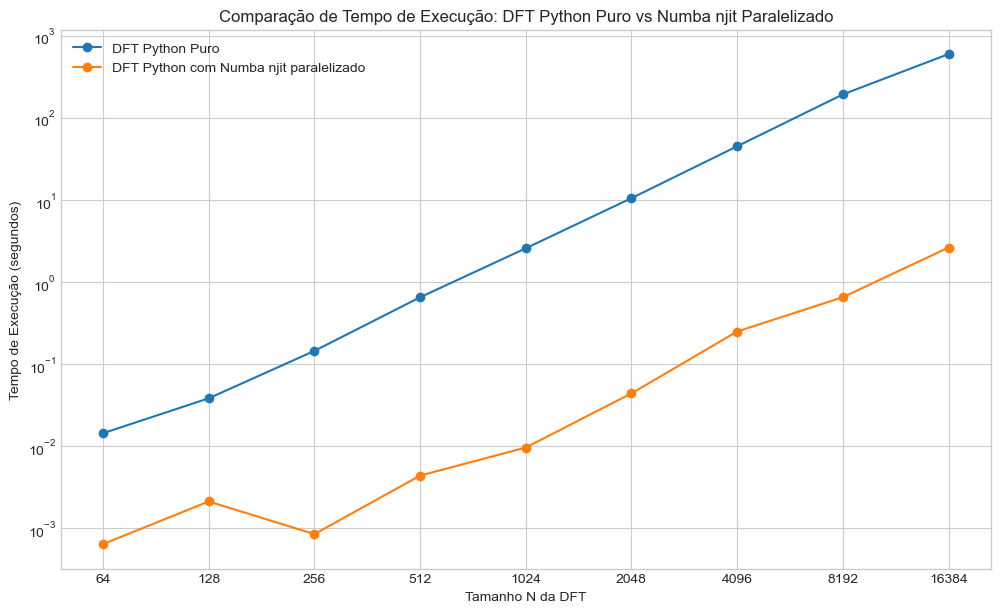

In [26]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, jit , vectorize , prange
@njit(parallel=True)
def DFT_func_Numba(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in prange(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT


def DFT_func(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in range(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT


dft_tamanhos= [64,128,256,512,1024,2048,4096,8192,16384]        
tempo_DFT= []
tempo_DFT_Numba= []

fs= 1000 # frequência de amostragem
f= 50 # frequência do sinal
A= 1 # amplitude do sinal
t= np.arange(-1,1,1/fs) # vetor tempo
x= A * np.sin(2 * np.pi * f * t) # sinal senoidal
x_noise= x + 0.5 * np.random.randn(len(t)) # sinal com ruído

print("Primeira Compilação com Numba (pode demorar um pouco)...")
DFT_func_Numba(x_noise, 100) # Compilação inicial com Numba
print("Compilação concluída. Iniciando os testes de tempo...")

for N in dft_tamanhos:
    print(f'Para N= {N}...')
    
    start_time= time.perf_counter()
    X_DFT= DFT_func(x_noise,N)
    end_time= time.perf_counter()
    time_spent= end_time - start_time
    tempo_DFT.append(time_spent)
    print(f'Tempo DFT com python puro: {time_spent} segundos')

    start_time_n= time.perf_counter()
    X_DFT= DFT_func_Numba(x_noise,N)
    end_time_n= time.perf_counter()
    time_spent_n= end_time_n - start_time_n
    tempo_DFT_Numba.append(time_spent_n)
    print(f'Tempo DFT tempo com python com njit paralelizado: {time_spent_n} segundos')

plt.figure(figsize=(12,7))
plt.plot(dft_tamanhos, tempo_DFT, marker='o', label='DFT Python Puro')
plt.plot(dft_tamanhos, tempo_DFT_Numba, marker='o', label='DFT Python com Numba njit paralelizado')
plt.yscale('log')
plt.xscale('log', base=2)
plt.xlabel('Tamanho N da DFT')
plt.ylabel('Tempo de Execução (segundos)')
plt.title('Comparação de Tempo de Execução: DFT Python Puro vs Numba njit Paralelizado')
plt.xticks (dft_tamanhos, labels=dft_tamanhos)
plt.legend()
plt.show()


    